In [110]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 

In [111]:
words = open("names.txt", "r").read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [112]:
chars = sorted(list(set("".join(words))))

stoi = {s:i + 1 for i, s in enumerate(chars)}
stoi["."] = 0 

itos = {i:s for s,i in stoi.items()}

In [113]:
# build dataset 

block_size = 3 

def build_dataset(words):
    X, Y = [], [] 

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random 
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [114]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '---->', itos[y.item()])

... ----> y
..y ----> u
.yu ----> h
yuh ----> e
uhe ----> n
hen ----> g
eng ----> .
... ----> d
..d ----> i
.di ----> o
dio ----> n
ion ----> d
ond ----> r
ndr ----> e
dre ----> .
... ----> x
..x ----> a
.xa ----> v
xav ----> i
avi ----> e


In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn(fan_in, fan_out, generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None 
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out 
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        # constants 
        self.eps = eps
        self.momentum = momentum
        self.training = True 
        # trainable parameters 
        self.gamma = torch.ones(dim) # scale
        self.beta = torch.zeros(dim) # shift
        # running mean and var
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass 
        if self.training: 
            xmean = x.mean(0, keepdim=True) # batch mean 
            xvar = x.var(0, keepdim=True) # batch variance 
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # standardize normalization 
        self.out = self.gamma * xhat + self.beta # scale and shift 
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean 
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar 

        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self): 
        return [] # tanh has no parameters 

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]

    def parameters(self):
        return [self.weight]

In [116]:
torch.manual_seed(42)

In [117]:
n_embd = 10 # dimensionality of the character embedding vectors 
n_hidden = 200 # number of neurons at the hidden layers of the mlp 
vocab_size = 27
block_size = 3

C = torch.randn(vocab_size, n_embd)

layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm(n_hidden), Tanh(),
    Linear(             n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1 # make last layer less confident 


parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters)) # total number of parameter 

for p in parameters:
    p.requires_grad = True 

12097


In [118]:
# Training loop 

max_steps = 200_000
batch_size = 32 
lossi = [] 

for i in range(max_steps):

    # mini batch construct 
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)

    # forward pass 
    emb = C[Xtr[ix]]
    x = emb.view(emb.shape[0], -1)
    for layer in layers: 
        x = layer(x)
    loss = F.cross_entropy(x, Ytr[ix]) # loss function 

    # backward pass 
    for layer in layers: 
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None 
    loss.backward()

    # update 
    lr = 0.1 if i < 150_000 else 0.01 # applied learning rate decay 
    for p in parameters:
        p.data -= lr * p.grad

    # track stats 
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0/ 200000: 3.2787
  10000/ 200000: 2.2961
  20000/ 200000: 2.3664
  30000/ 200000: 2.2574
  40000/ 200000: 2.3682
  50000/ 200000: 2.1701
  60000/ 200000: 2.0064
  70000/ 200000: 2.2603
  80000/ 200000: 2.2668
  90000/ 200000: 2.0089
 100000/ 200000: 1.7937
 110000/ 200000: 2.1012
 120000/ 200000: 1.8777
 130000/ 200000: 2.0657
 140000/ 200000: 1.8944
 150000/ 200000: 2.2891
 160000/ 200000: 1.8671
 170000/ 200000: 1.8799
 180000/ 200000: 1.8530
 190000/ 200000: 1.9195


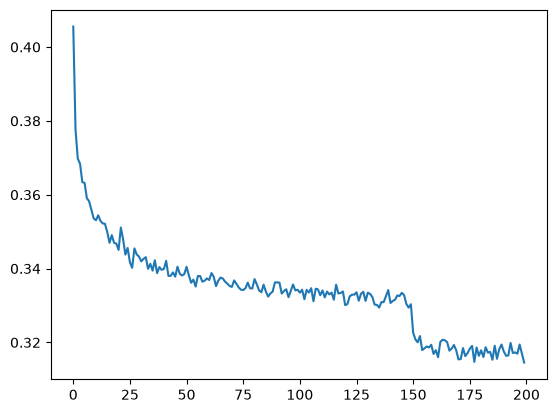

In [119]:
#plt.plot(lossi)

# A better way of plotting the loss function to look nice

plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [120]:
# put layers into training model since we are using batch norm 
for layer in layers:
    layer.training = False

In [121]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0612573623657227
val 2.107168436050415


In [122]:
# Sample from the model 

for _ in range(20):
    out = [] 
    context = [0] * block_size
    while True: 
        # forward pass 
        emb = C[torch.tensor([context])] 
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        logits = x 
        probs = F.softmax(logits, dim=1)
        # Sample from the distribution 
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window 
        context = context[1:] + [ix]
        out.append(ix)
        # if the sampled token is '.', break!! 
        if ix == 0:
            break

    # convert the interger indexes to letters and print 
    print(''.join(itos[i] for i in out)) 

avelasetusaimy.
paesiro.
kadia.
avryceo.
olandellaver.
mika.
emrelyn.
georgan.
zachidane.
iviana.
shna.
aal.
kate.
ellandolh.
brayingley.
and.
jamari.
jan.
lore.
dannaleigh.
